In [1]:
#!/usr/bin/env python3
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


try:
    import imageio.v2 as imageio
    HAS_IMAGEIO = True
except Exception:
    HAS_IMAGEIO = False
    from PIL import Image



ROOT = "/Users/dashakan/Desktop/scripts_AIS"
CST_FILE = os.path.join(ROOT, "MARcst-AN35km-176x148.cdf2")

FORCING_LABEL = "UKM"
NC_FILE = os.path.join(ROOT, "year-MAR-DS_UKM-1980-2100.nc")  # or nDS 

BASE_YEAR = 1980
YEAR0, YEAR1 = 1980, 2100  # GIF span


#   "mean" -> animate ME magnitude
#   "occ"  -> animate ME > 0 occurrence (0/1)
MODE = "occ"
ME_THR = 0.0  # used only if MODE="occ"

FPS = 6
DPI = 160

OUTDIR = os.path.join(ROOT, "figs_gif")
os.makedirs(OUTDIR, exist_ok=True)
OUTGIF = os.path.join(OUTDIR, f"{FORCING_LABEL}_ME_{MODE}_grounded_vs_shelves_{YEAR0}_{YEAR1}.gif")




def get_time_dim(ds):
    if "TIME" in ds.dims:
        return "TIME"
    if "time" in ds.dims:
        return "time"
    raise ValueError("No TIME/time dimension found")

def to_2d_yx(da):
    da = da.squeeze(drop=True)
    while da.ndim > 2:
        extra = [d for d in da.dims if d not in ("Y", "X")]
        da = da.isel({(extra[0] if extra else da.dims[0]): 0}).squeeze(drop=True)
    if set(("Y", "X")).issubset(set(da.dims)):
        da = da.transpose("Y", "X")
    return np.asarray(da.values)

def build_masks(cst_path):
    msk = xr.open_dataset(cst_path)
    ICE = to_2d_yx(msk["ICE"]).astype(bool)
    GROUND = to_2d_yx(msk["GROUND"]).astype(bool)
    SHELF = ICE & (~GROUND)
    X2D, Y2D = np.meshgrid(msk["X"].values, msk["Y"].values)
    return {"ICE": ICE, "GROUND": GROUND, "SHELF": SHELF, "X2D": X2D, "Y2D": Y2D}

def year_to_index(y, base_year):
    return y - base_year

def add_outlines(ax, M):
    X2D, Y2D = M["X2D"], M["Y2D"]
    ax.contour(X2D, Y2D, M["ICE"].astype(float), levels=[0.5], linewidths=0.6)
    ax.contour(X2D, Y2D, (M["ICE"] & M["GROUND"]).astype(float), levels=[0.5], linewidths=1.0)
    ax.contour(X2D, Y2D, M["SHELF"].astype(float), levels=[0.5], linewidths=1.0)

def compute_global_vmax(ds, M, tdim, i0, i1, mode):
 
    vals = []
    step = max(1, (i1 - i0) // 30)  # sample ~30 frames for speed
    for i in range(i0, i1 + 1, step):
        me = ds["ME"].isel({tdim: i})
        me2 = to_2d_yx(me)
        if mode == "occ":
            me2 = (me2 > ME_THR).astype(float)
        else:
            me2 = np.where(np.isfinite(me2), me2, np.nan)
        me2 = np.where(M["ICE"], me2, np.nan)
        vals.append(me2)
    stack = np.array(vals)
    finite = np.isfinite(stack)
    if not finite.any():
        return 1.0
    return float(np.nanpercentile(stack[finite], 99))

def frame_to_image(fig):
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    return buf[:, :, :3]   





def main():
    M = build_masks(CST_FILE)
    ds = xr.open_dataset(NC_FILE, decode_times=False)

    tdim = get_time_dim(ds)
    n = ds.dims[tdim]

    i0 = max(0, year_to_index(YEAR0, BASE_YEAR))
    i1 = min(n - 1, year_to_index(YEAR1, BASE_YEAR))

    if i0 > i1:
        raise RuntimeError("Requested year window is empty. Check BASE_YEAR and file length.")

    if "ME" not in ds:
        raise KeyError(f"'ME' not found in {NC_FILE}. Available: {list(ds.data_vars)}")

    vmax = compute_global_vmax(ds, M, tdim, i0, i1, MODE)
    vmin = 0.0

    frames = []

    for i in range(i0, i1 + 1):
        year = BASE_YEAR + i

        me = ds["ME"].isel({tdim: i})
        me2 = to_2d_yx(me)

        if MODE == "occ":
            field = (me2 > ME_THR).astype(float)  # 0/1
            cbar_label = f"Melt occurrence (ME > {ME_THR})"
            vmax_use = 1.0
        else:
            field = me2
            cbar_label = "Melt (ME) kg m⁻² yr⁻¹)"
            vmax_use = vmax

        grounded = np.where(M["ICE"] & M["GROUND"], field, np.nan)
        shelves  = np.where(M["SHELF"], field, np.nan)

     
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

        im1 = ax1.pcolormesh(M["X2D"], M["Y2D"], grounded, shading="auto",cmap="RdBu_r", vmin=vmin, vmax=vmax_use)

        ax1.set_aspect("equal", adjustable="box")
        ax1.set_title("Grounded ice")
        ax1.axis("off")
        add_outlines(ax1, M)

        im2 = ax2.pcolormesh(M["X2D"], M["Y2D"], shelves, shading="auto",cmap="RdBu_r", vmin=vmin, vmax=vmax_use)
        ax2.set_aspect("equal", adjustable="box")
        ax2.set_title("Ice shelves")
        ax2.axis("off")
        add_outlines(ax2, M)

        cb = fig.colorbar(im2, ax=[ax1, ax2], shrink=0.85)
        cb.set_label(cbar_label)

        fig.suptitle(f"{FORCING_LABEL} | ME  | Year {year}", fontsize=14)

        img = frame_to_image(fig)
        frames.append(img)
        plt.close(fig)

    # --- write gif ---
    if HAS_IMAGEIO:
        imageio.mimsave(OUTGIF, frames, fps=FPS)
    else:
        pil_frames = [Image.fromarray(fr) for fr in frames]
        pil_frames[0].save(
            OUTGIF,
            save_all=True,
            append_images=pil_frames[1:],
            duration=int(1000 / FPS),
            loop=0
        )

    print("Saved GIF:", OUTGIF)


if __name__ == "__main__":
    main()


/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_50754/2254753092.py:108: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n = ds.dims[tdim]


Saved GIF: /Users/dashakan/Desktop/scripts_AIS/figs_gif/UKM_ME_occ_grounded_vs_shelves_1980_2100.gif


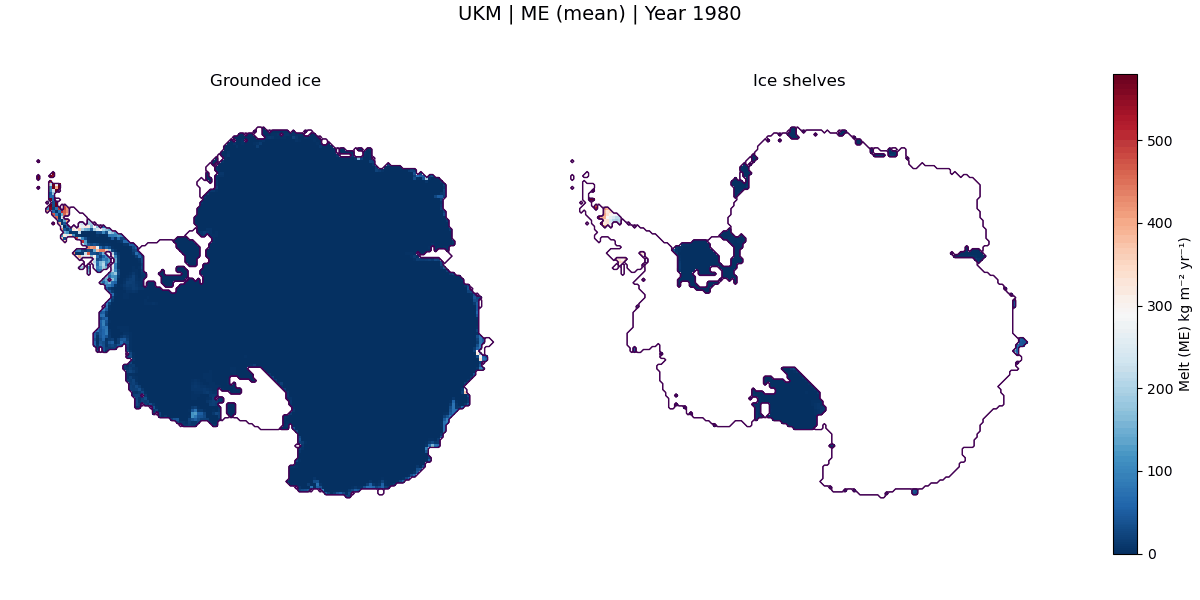

In [6]:
from IPython.display import Image, display

display(Image(filename="figs_gif/UKM_ME_mean_grounded_vs_shelves_1980_2100.gif"))
